# 6CS012 — Final Portfolio Project
## Part III: Text Classification with RNN / LSTM
### Spam vs Ham SMS Detection

| | |
|---|---|
| **Student Name** | Adarsha Prasai |
| **Student ID** | 2408599 |
| **Dataset** | SMS Spam Collection v.1 (5 572 messages, binary) |
| **Group** | L6CG8 |
| **Module Leader** | Siman Giri |
| **Tutor** | Durga Pokharel |

---
### Table of Contents
1. [Setup & Imports](#setup)
2. [Data Loading & Exploration](#eda)
3. [Text Preprocessing, Tokenisation & Padding](#prep)
4. [Model 1 — Simple RNN](#rnn)
5. [Model 2 — LSTM (Trainable Embedding)](#lstm)
6. [Model 3 — LSTM (Word2Vec Embedding)](#w2v)
7. [Evaluation & Comparison](#eval)
8. [Error Analysis](#error)
9. [Real-Time Prediction GUI](#gui)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import subprocess, sys

# Install missing packages
subprocess.check_call([sys.executable, "-m", "pip", "install", "gensim", "wordcloud", "nltk", "-q"])

import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import gensim
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"Gensim     : {gensim.__version__}")


TensorFlow : 2.20.0
Gensim     : 4.4.0


## 1. Setup & Imports <a id='setup'></a>


In [6]:
# ── Configuration ─────────────────────────────────────────────
import os

# Auto-detect path: works locally and on Colab
_LOCAL = (
    '/Users/adarshaprasai/Desktop/Herald/FinalYear/Sem2/AIML/Port/'
    'Collection of Dataset for Text Classification/'
    '9.Spam vs Ham Sms Dataset/spamvsham.csv'
)
_COLAB = '/content/drive/MyDrive/aiml/9.Spam vs Ham Sms Dataset/spamvsham.csv'

DATA_PATH = _LOCAL if os.path.exists(_LOCAL) else _COLAB
print(f'Dataset path : {DATA_PATH}')
assert os.path.exists(DATA_PATH), f'File not found — update DATA_PATH: {DATA_PATH}'

TEST_SIZE    = 0.20     # 80 / 20 split as required
SEED         = 42
VAL_SPLIT    = 0.15     # fraction of training set used for validation curves

EMBED_DIM_12 = 64       # embedding dim for Model 1 & 2
EMBED_DIM_3  = 100      # Word2Vec vector size for Model 3
W2V_WINDOW   = 5
W2V_MINCOUNT = 1

EPOCHS       = 20
BATCH_SIZE   = 64

print('Configuration loaded.')


Dataset path : /content/drive/MyDrive/aiml/9.Spam vs Ham Sms Dataset/spamvsham.csv
Configuration loaded.


## 2. Data Loading & Exploration <a id='eda'></a>

### 2.1 Dataset Description

The **SMS Spam Collection v.1** is a publicly available labelled corpus of 5 572 real English SMS messages. Each message is tagged as either `ham` (legitimate) or `spam`. The messages contain informal language, abbreviations, slang, phone numbers, and promotional URLs — making it an ideal dataset for evaluating NLP preprocessing pipelines and sequence models.

| Property | Value |
|---|---|
| Total messages | 5 572 |
| Classes | 2 (ham = 0, spam = 1) |
| Ham messages | ~4 827 (86.6%) |
| Spam messages | ~745 (13.4%) |
| Imbalance ratio | ~6.5 : 1 |

The dataset is **imbalanced** — a classifier that always predicts ham would achieve ~87% accuracy. This makes F1-score on the spam class the primary evaluation metric rather than raw accuracy.


In [7]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'text']
df['label_enc'] = (df['label'] == 'spam').astype(int)   # ham=0, spam=1
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f'Shape          : {df.shape}')
print(f'Null values    : {df.isnull().sum().sum()}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
print(f'\nClass proportions:')
print(df['label'].value_counts(normalize=True).round(4))
df.head()


Shape          : (5572, 3)
Null values    : 0

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class proportions:
label
ham     0.8659
spam    0.1341
Name: proportion, dtype: float64


,label,text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


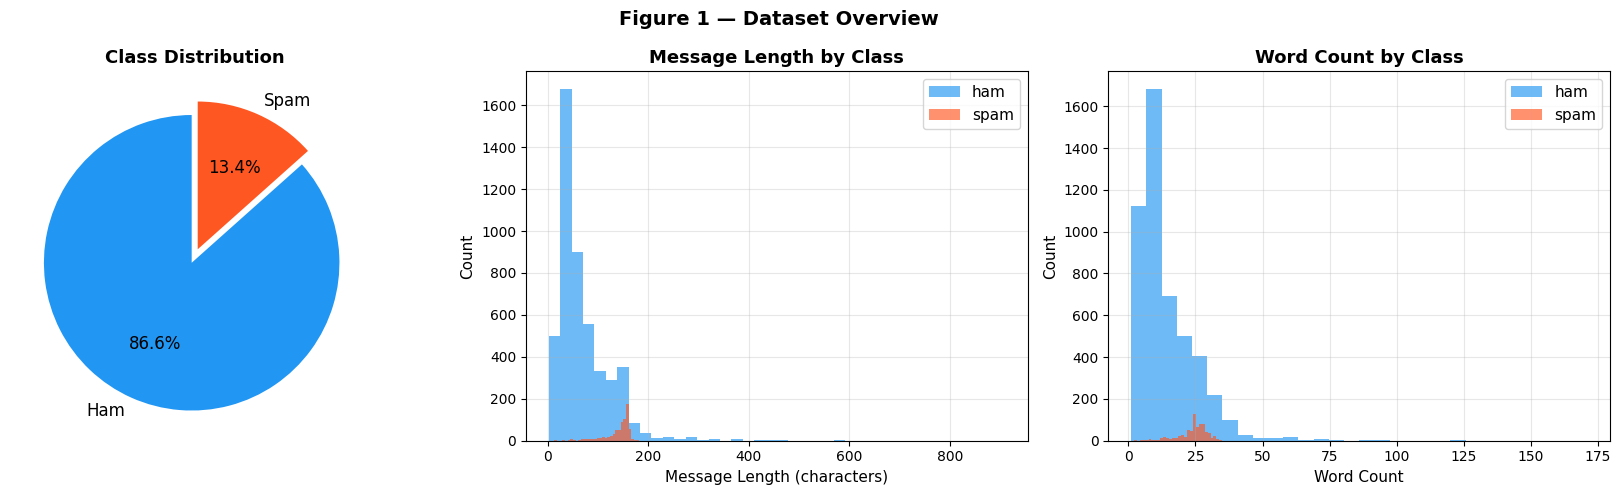

Average char length per class:
label
ham      71.0
spam    138.9
Name: char_len, dtype: float64


In [8]:
# ── Figure 1 : Overview — Class Distribution & Message Lengths
df['char_len']  = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Ham', 'Spam'],
            autopct='%1.1f%%', colors=['#2196F3', '#FF5722'],
            explode=(0.05, 0.05), startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Char length
for lbl, col in [('ham', '#2196F3'), ('spam', '#FF5722')]:
    axes[1].hist(df[df['label'] == lbl]['char_len'],
                 bins=40, alpha=0.65, color=col, label=lbl)
axes[1].set_xlabel('Message Length (characters)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Message Length by Class', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

# Word count
for lbl, col in [('ham', '#2196F3'), ('spam', '#FF5722')]:
    axes[2].hist(df[df['label'] == lbl]['word_count'],
                 bins=30, alpha=0.65, color=col, label=lbl)
axes[2].set_xlabel('Word Count', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('Word Count by Class', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11); axes[2].grid(alpha=0.3)

plt.suptitle('Figure 1 — Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average char length per class:')
print(df.groupby('label')['char_len'].mean().round(1))


## 3. Text Preprocessing, Tokenisation & Padding <a id='prep'></a>

### 3.1 Preprocessing Steps

| Step | Rationale |
|---|---|
| Lowercase | Removes case-based duplicates (`Free` vs `free`) |
| Contraction expansion | `don't` → `do not` preserves negation semantics |
| Remove URLs | Links carry no sentiment signal and inflate vocabulary |
| Remove @mentions and #hashtags | Not present in SMS; safety step |
| Remove digits | Phone numbers and prize amounts are spam indicators, but also noise |
| Remove special characters | Punctuation adds vocabulary noise |
| Remove stopwords | High-frequency functional words ("the", "is") add noise |
| Lemmatisation | Reduces inflected forms to base ("winning" → "win") |


In [9]:
CONTRACTIONS = {
    "ain't": 'am not', "aren't": 'are not', "can't": 'cannot',
    "could've": 'could have', "couldn't": 'could not',
    "didn't": 'did not', "doesn't": 'does not', "don't": 'do not',
    "hadn't": 'had not', "hasn't": 'has not', "haven't": 'have not',
    "he'd": 'he would', "he'll": 'he will', "he's": 'he is',
    "i'd": 'i would', "i'll": 'i will', "i'm": 'i am', "i've": 'i have',
    "isn't": 'is not', "it's": 'it is', "let's": 'let us',
    "mustn't": 'must not', "shan't": 'shall not',
    "she'd": 'she would', "she'll": 'she will', "she's": 'she is',
    "shouldn't": 'should not', "that's": 'that is',
    "there's": 'there is', "they'd": 'they would',
    "they'll": 'they will', "they're": 'they are', "they've": 'they have',
    "we'd": 'we would', "we're": 'we are', "we've": 'we have',
    "weren't": 'were not', "what's": 'what is', "where's": 'where is',
    "who's": 'who is', "won't": 'will not', "wouldn't": 'would not',
    "you'd": 'you would', "you'll": 'you will',
    "you're": 'you are', "you've": 'you have',
}

def expand_contractions(text):
    for contr, full in CONTRACTIONS.items():
        text = text.replace(contr, full)
    return text

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'@\w+|#\w+', ' ', text)              # mentions / hashtags
    text = re.sub(r'\d+', ' ', text)                     # digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)            # special chars
    text = re.sub(r'\s+', ' ', text).strip()             # extra whitespace
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print('Preprocessing done. Before / after samples:')
for i in [0, 3, 50, 200]:
    print(f'\n  ORIGINAL : {df.iloc[i]["text"][:90]}')
    print(f'  CLEANED  : {df.iloc[i]["clean_text"][:90]}')


Preprocessing done. Before / after samples:

  ORIGINAL : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine t
  CLEANED  : go jurong point crazy available bugis great world la buffet cine got amore wat

  ORIGINAL : U dun say so early hor... U c already then say...
  CLEANED  : dun say early hor already say

  ORIGINAL : What you thinked about me. First time you saw me in class.
  CLEANED  : thinked first time saw class

  ORIGINAL : I sent you  &lt;#&gt;  bucks
  CLEANED  : sent lt gt buck


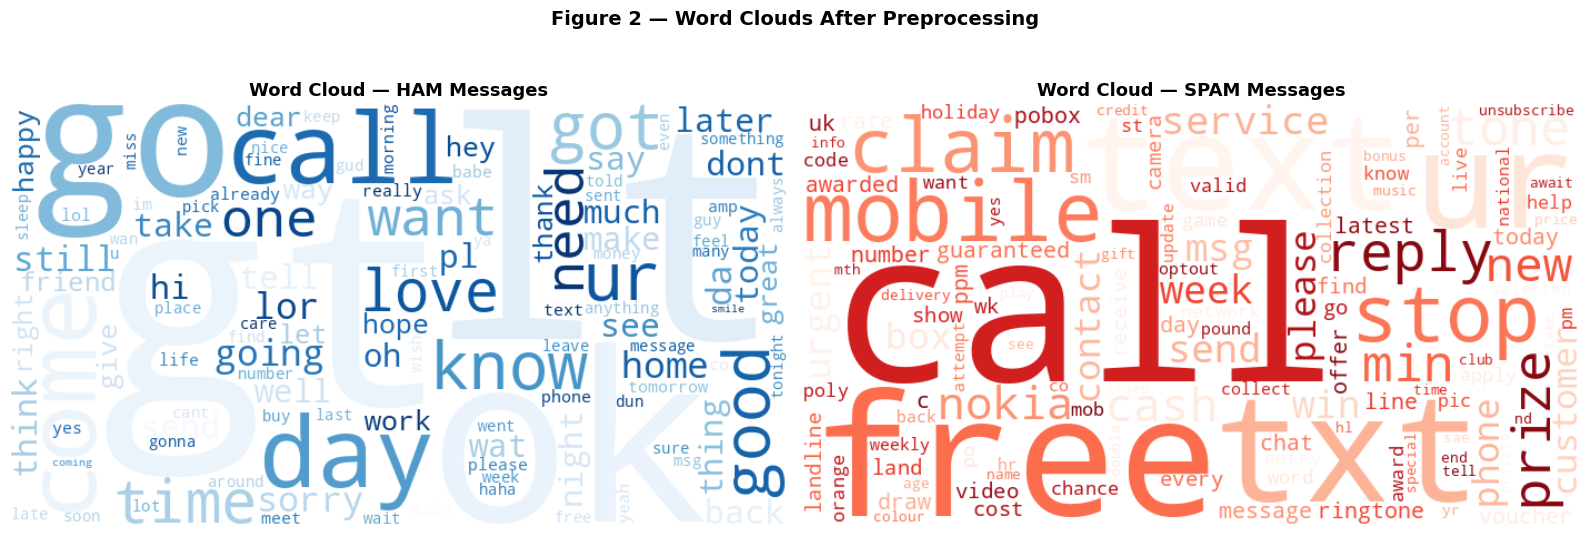

In [10]:
# ── Figure 2 : Word Clouds — Ham vs Spam ──────────────────────
ham_text  = ' '.join(df[df['label'] == 'ham']['clean_text'])
spam_text = ' '.join(df[df['label'] == 'spam']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, txt, title, cmap in [
    (axes[0], ham_text,  'HAM Messages',  'Blues'),
    (axes[1], spam_text, 'SPAM Messages', 'Reds'),
]:
    wc = WordCloud(
        width=700, height=380, background_color='white',
        colormap=cmap, max_words=120, collocations=False
    ).generate(txt)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {title}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Figure 2 — Word Clouds After Preprocessing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


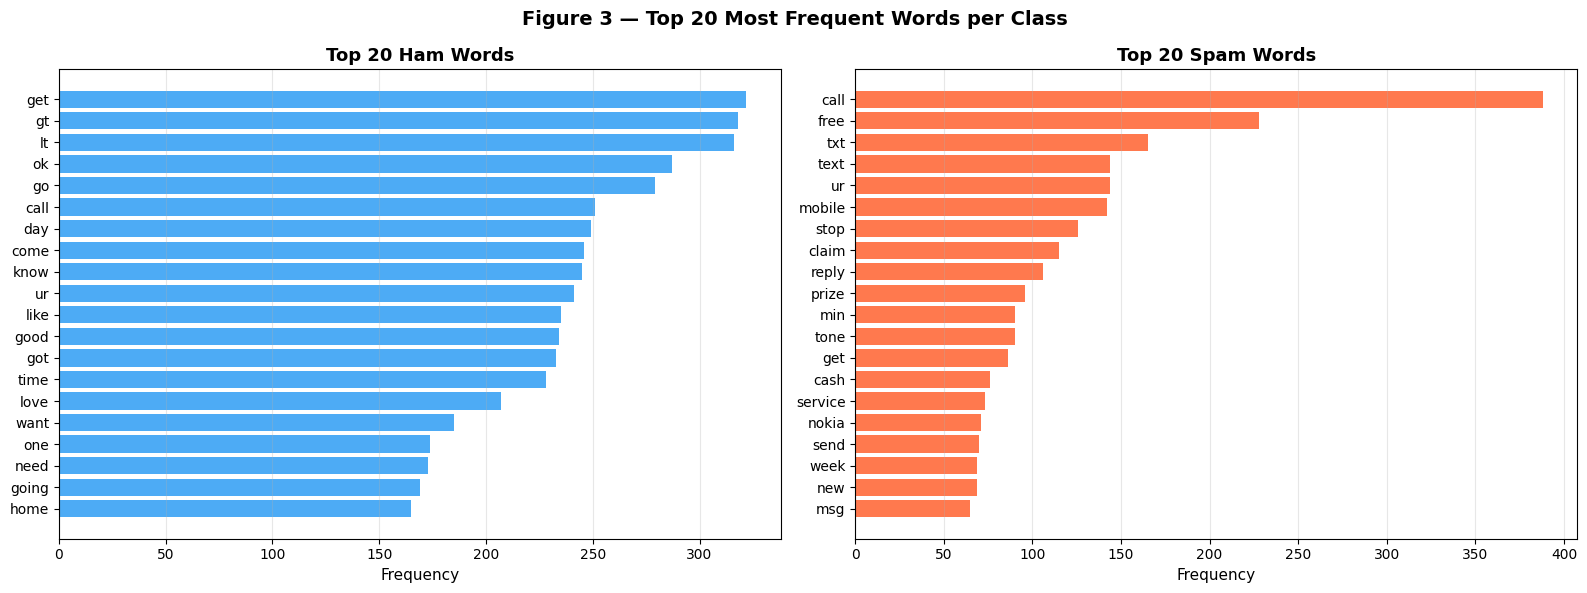

In [11]:
# ── Figure 3 : Top 20 Words per Class ─────────────────────────
def top_n_words(series, n=20):
    words = ' '.join(series).split()
    return Counter(words).most_common(n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for ax, label_str, col, title in [
    (ax1, 'ham',  '#2196F3', 'Top 20 Ham Words'),
    (ax2, 'spam', '#FF5722', 'Top 20 Spam Words'),
]:
    top = top_n_words(df[df['label'] == label_str]['clean_text'])
    words, freqs = zip(*top)
    ax.barh(range(len(words)), freqs, color=col, alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Figure 3 — Top 20 Most Frequent Words per Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Train / Test Split


In [12]:
X = df['clean_text'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

print(f'Training   : {len(X_train)} samples  (spam: {y_train.sum()})')
print(f'Test       : {len(X_test)}  samples  (spam: {y_test.sum()})')
print(f'Train spam : {y_train.mean()*100:.1f}%')
print(f'Test  spam : {y_test.mean()*100:.1f}%  (stratification confirmed)')


Training   : 4457 samples  (spam: 598)
Test       : 1115  samples  (spam: 149)
Train spam : 13.4%
Test  spam : 13.4%  (stratification confirmed)


### 3.3 Tokenisation & Padding


Vocabulary size (incl. <OOV>) : 6222
Sequence lengths — min: 0, mean: 8.4, max: 75
95th percentile (chosen MAX_LEN) : 19


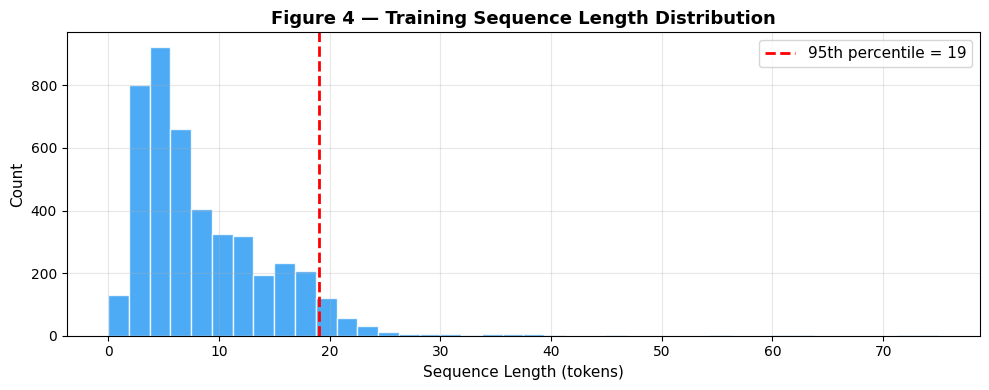

In [13]:
# Fit tokeniser on TRAINING data only
# assign each unique word a unique number
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index)

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# Sequence length analysis — choose MAX_LEN from 95th percentile
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 95))

print(f'Vocabulary size (incl. <OOV>) : {vocab_size}')
print(f'Sequence lengths — min: {np.min(lengths)}, '
      f'mean: {np.mean(lengths):.1f}, '
      f'max: {np.max(lengths)}')
print(f'95th percentile (chosen MAX_LEN) : {MAX_LEN}')

# ── Figure 4 : Sequence Length Distribution ───────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=40, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(MAX_LEN, color='red', lw=2, ls='--',
           label=f'95th percentile = {MAX_LEN}')
ax.set_xlabel('Sequence Length (tokens)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Figure 4 — Training Sequence Length Distribution',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_seq_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Pad sequences (post-padding and post-truncation)
X_train_pad = pad_sequences(
    train_seqs, maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad = pad_sequences(
    test_seqs, maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f'X_train shape : {X_train_pad.shape}')
print(f'X_test  shape : {X_test_pad.shape}')


X_train shape : (4457, 19)
X_test  shape : (1115, 19)


In [15]:
# ── Word2Vec — trained on training corpus (for Model 3) ───────
train_sentences = [text.split() for text in X_train]

print(f'Training Word2Vec on {len(train_sentences)} sentences...')
w2v = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBED_DIM_3,
    window=W2V_WINDOW,
    min_count=W2V_MINCOUNT,
    workers=4,
    seed=SEED,
    epochs=15,
)
print(f'Word2Vec vocab size : {len(w2v.wv)}')

# Build embedding matrix aligned with Keras tokeniser
embedding_matrix = np.zeros((vocab_size + 1, EMBED_DIM_3))
covered, missing = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx <= vocab_size:
        if word in w2v.wv:
            embedding_matrix[idx] = w2v.wv[word]
            covered += 1
        else:
            missing += 1

coverage = covered / (covered + missing) * 100
print(f'Embedding matrix shape : {embedding_matrix.shape}')
print(f'Words with W2V vectors : {covered} ({coverage:.1f}%)')
print(f'Words defaulting to 0  : {missing} ({100-coverage:.1f}%)')


Training Word2Vec on 4457 sentences...
Word2Vec vocab size : 6221
Embedding matrix shape : (6223, 100)
Words with W2V vectors : 6221 (100.0%)
Words defaulting to 0  : 1 (0.0%)


In [16]:
# ── Shared Callbacks & Storage ────────────────────────────────
def get_callbacks(name, patience_es=4, patience_lr=2):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{name}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience_lr, min_lr=1e-6, verbose=0
        ),
    ]

all_histories = {}
all_times     = {}

print('Callbacks defined.')


Callbacks defined.


## 4. Model 1 — Simple RNN with Trainable Embedding <a id='rnn'></a>

### Architecture

| Layer | Config |
|---|---|
| Embedding | input_dim = vocab+1, output_dim = 64, input_length = MAX_LEN, trainable = True |
| SimpleRNN | 64 units, dropout = 0.3 |
| Dense | 1 unit, sigmoid |

The SimpleRNN updates a hidden state at each time step using the current input and the previous hidden state. Its main limitation is the **vanishing gradient problem**: gradients shrink exponentially during backpropagation through time, making it difficult to learn dependencies between tokens that are far apart in the sequence. The LSTM architecture (Models 2 and 3) directly addresses this.


In [17]:
model1 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1, output_dim=EMBED_DIM_12,
        input_length=MAX_LEN, trainable=True, name='embedding'
    ),
    layers.SimpleRNN(64, dropout=0.3, name='simple_rnn'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model1_SimpleRNN')

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.summary()


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
print('Training Model 1 — SimpleRNN...')
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('rnn'),
    verbose=1,
)

all_times['Model 1 (SimpleRNN)']     = time.time() - t0
all_histories['Model 1 (SimpleRNN)'] = history1
print(f'Training time  : {all_times["Model 1 (SimpleRNN)"]:.1f}s')
print(f'Best val acc   : {max(history1.history["val_accuracy"]):.4f}')
print(f'Epochs run     : {len(history1.history["loss"])}')


Training Model 1 — SimpleRNN...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9205 - loss: 0.2267 - val_accuracy: 0.9596 - val_loss: 0.1454 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9836 - loss: 0.0612 - val_accuracy: 0.9671 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9923 - loss: 0.0347 - val_accuracy: 0.9656 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9952 - loss: 0.0199 - val_accuracy: 0.9402 - val_loss: 0.2664 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9963 - loss: 0.0148 - val_accuracy: 0.9701 - val_loss: 0.1184 - learning_rate: 5.0000e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9971 - loss: 0.0135 - val_accuracy: 0.9611 - val_loss: 0.1278 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the

## 5. Model 2 — LSTM with Trainable Embedding <a id='lstm'></a>

### Architecture

| Layer | Config |
|---|---|
| Embedding | input_dim = vocab+1, output_dim = 64, input_length = MAX_LEN, trainable = True |
| LSTM | 64 units, dropout = 0.3, recurrent_dropout = 0.2 |
| Dense | 1 unit, sigmoid |

The LSTM uses three gating mechanisms — **forget gate** (what to discard from memory), **input gate** (what new information to store), and **output gate** (what to pass to the next step) — which allow it to preserve long-range dependencies. This directly addresses the vanishing gradient limitation of the SimpleRNN.


In [19]:
model2 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1, output_dim=EMBED_DIM_12,
        input_length=MAX_LEN, trainable=True, name='embedding'
    ),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model2_LSTM')

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.summary()


Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
print('Training Model 2 — LSTM (trainable embedding)...')
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('lstm'),
    verbose=1,
)

all_times['Model 2 (LSTM)']     = time.time() - t0
all_histories['Model 2 (LSTM)'] = history2
print(f'Training time  : {all_times["Model 2 (LSTM)"]:.1f}s')
print(f'Best val acc   : {max(history2.history["val_accuracy"]):.4f}')
print(f'Epochs run     : {len(history2.history["loss"])}')


Training Model 2 — LSTM (trainable embedding)...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.8918 - loss: 0.2947 - val_accuracy: 0.9581 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9784 - loss: 0.0791 - val_accuracy: 0.9731 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9902 - loss: 0.0401 - val_accuracy: 0.9731 - val_loss: 0.0908 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9945 - loss: 0.0244 - val_accuracy: 0.9821 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9976 - loss: 0.0116 - val_accuracy: 0.9761 - val_loss: 0.0792 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9974 - loss: 0.0111 - val_accuracy: 0.9806 - val_loss: 0.0610 - learning_rate: 0.0010
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 90

## 6. Model 3 — LSTM with Word2Vec Embeddings <a id='w2v'></a>

### Architecture

| Layer | Config |
|---|---|
| Embedding | input_dim = vocab+1, output_dim = **100**, weights = W2V matrix, **trainable = False** |
| LSTM | 64 units, dropout = 0.3, recurrent_dropout = 0.2 |
| Dense | 64 units, ReLU |
| Dense | 1 unit, sigmoid |

The embedding layer is initialised with **Word2Vec** vectors trained on the SMS training corpus and then **frozen** during model training. Words that appear in similar contexts share similar vector representations. This provides the LSTM with richer initial token representations compared to randomly initialised embeddings in Models 1 and 2.


In [21]:
model3 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1, output_dim=EMBED_DIM_3,
        weights=[embedding_matrix], input_length=MAX_LEN,
        trainable=False, name='w2v_embedding'
    ),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
    layers.Dense(64, activation='relu', name='fc'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model3_LSTM_W2V')

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Force build so count_params() works
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

total_p     = model3.count_params()
trainable_p = sum(int(np.prod(v.shape)) for v in model3.trainable_weights)
print(f'\nTotal params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}  (embedding frozen)')
print(f'Frozen params    : {total_p - trainable_p:,}')


Model: "Model3_LSTM_W2V"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ (None, 19, 100)        │       622,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,765 (2.55 MB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 622,300 (2.37 MB)


Total params     : 668,765
Trainable params : 46,465  (embedding frozen)
Frozen params    : 622,300


In [22]:
print('Training Model 3 — LSTM (Word2Vec embedding)...')
t0 = time.time()

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('lstm_w2v'),
    verbose=1,
)

all_times['Model 3 (LSTM+W2V)']     = time.time() - t0
all_histories['Model 3 (LSTM+W2V)'] = history3
print(f'Training time  : {all_times["Model 3 (LSTM+W2V)"]:.1f}s')
print(f'Best val acc   : {max(history3.history["val_accuracy"]):.4f}')
print(f'Epochs run     : {len(history3.history["loss"])}')


Training Model 3 — LSTM (Word2Vec embedding)...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9261 - loss: 0.2590 - val_accuracy: 0.9507 - val_loss: 0.1482 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9636 - loss: 0.1135 - val_accuracy: 0.9522 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9678 - loss: 0.1023 - val_accuracy: 0.9581 - val_loss: 0.1250 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9649 - loss: 0.1029 - val_accuracy: 0.9567 - val_loss: 0.1165 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9691 - loss: 0.0965 - val_accuracy: 0.9596 - val_loss: 0.1217 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9665 - loss: 0.0935 - val_accuracy: 0.9581 - val_loss: 0.1137 - learning_rate: 0.0010
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/

## 7. Training Curves & Evaluation <a id='eval'></a>

### 7.1 Training vs Validation Curves — All Models


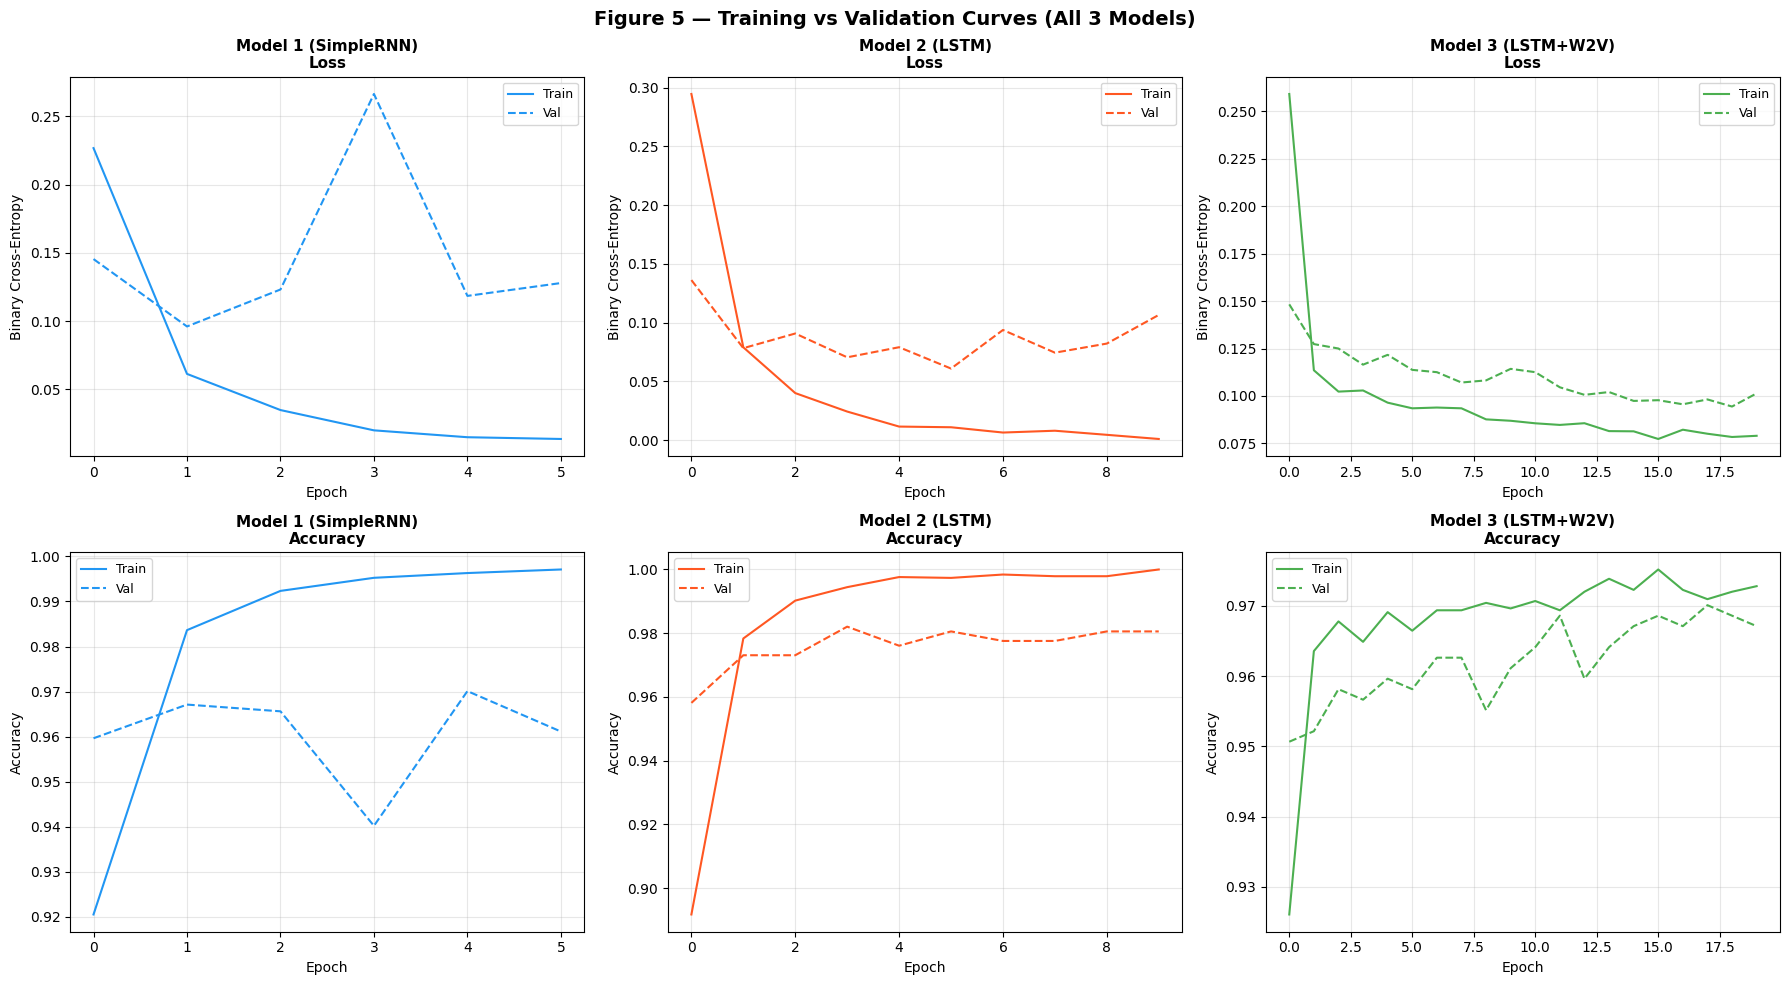

In [23]:
# ── Figure 5 : Training Curves (3 models, 2 rows) ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pal = ['#2196F3', '#FF5722', '#4CAF50']

for col_i, (name, hist) in enumerate(all_histories.items()):
    c = pal[col_i]
    # Loss row
    axes[0, col_i].plot(hist.history['loss'],     c=c, ls='-',  label='Train')
    axes[0, col_i].plot(hist.history['val_loss'], c=c, ls='--', label='Val')
    axes[0, col_i].set_title(f'{name}\nLoss', fontsize=11, fontweight='bold')
    axes[0, col_i].set_xlabel('Epoch')
    axes[0, col_i].set_ylabel('Binary Cross-Entropy')
    axes[0, col_i].legend(fontsize=9)
    axes[0, col_i].grid(alpha=0.3)
    # Accuracy row
    axes[1, col_i].plot(hist.history['accuracy'],     c=c, ls='-',  label='Train')
    axes[1, col_i].plot(hist.history['val_accuracy'], c=c, ls='--', label='Val')
    axes[1, col_i].set_title(f'{name}\nAccuracy', fontsize=11, fontweight='bold')
    axes[1, col_i].set_xlabel('Epoch')
    axes[1, col_i].set_ylabel('Accuracy')
    axes[1, col_i].legend(fontsize=9)
    axes[1, col_i].grid(alpha=0.3)

plt.suptitle('Figure 5 — Training vs Validation Curves (All 3 Models)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Test-Set Evaluation


In [24]:
def evaluate_model(model, X, y, model_name='Model'):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print()
    print(classification_report(y, y_pred,
          target_names=['Ham (0)', 'Spam (1)']))

    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                linewidths=0.5, ax=ax, annot_kws={'size': 14})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{model_name}\nConfusion Matrix (Test Set)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('(','').replace(')','').replace('+','')
    plt.savefig(f'cm_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print('evaluate_model() defined.')


evaluate_model() defined.



  Model 1 (SimpleRNN)
  Test Accuracy : 0.9803  (98.03%)

              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       0.98      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



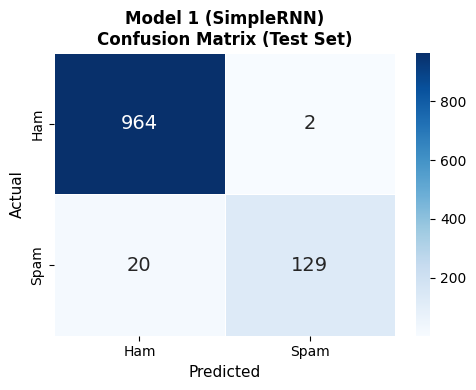


  Model 2 (LSTM)
  Test Accuracy : 0.9794  (97.94%)

              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99       966
    Spam (1)       0.93      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



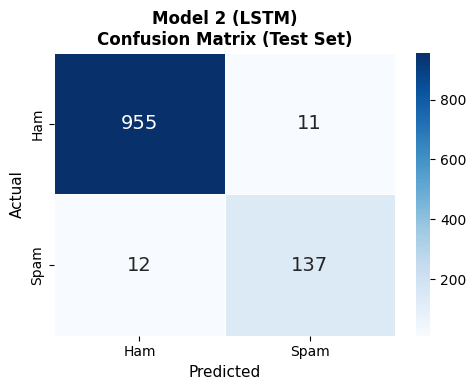


  Model 3 (LSTM + W2V)
  Test Accuracy : 0.9812  (98.12%)

              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       966
    Spam (1)       0.96      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



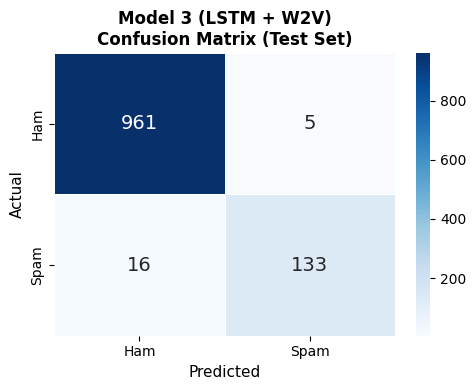

In [25]:
m1_metrics = evaluate_model(model1, X_test_pad, y_test, 'Model 1 (SimpleRNN)')
m2_metrics = evaluate_model(model2, X_test_pad, y_test, 'Model 2 (LSTM)')
m3_metrics = evaluate_model(model3, X_test_pad, y_test, 'Model 3 (LSTM + W2V)')



  MODEL COMPARISON — TEST SET
                     Accuracy  Precision (Spam)  Recall (Spam)  F1 (Spam)  Train Time (s) Parameters  Epochs
Model 1 (SimpleRNN)    0.9803            0.9847         0.8658     0.9214            10.3    406,593     6.0
Model 2 (LSTM)         0.9794            0.9257         0.9195     0.9226            59.8    431,361    10.0
Model 3 (LSTM+W2V)     0.9812            0.9638         0.8926     0.9268           101.9    668,765    20.0


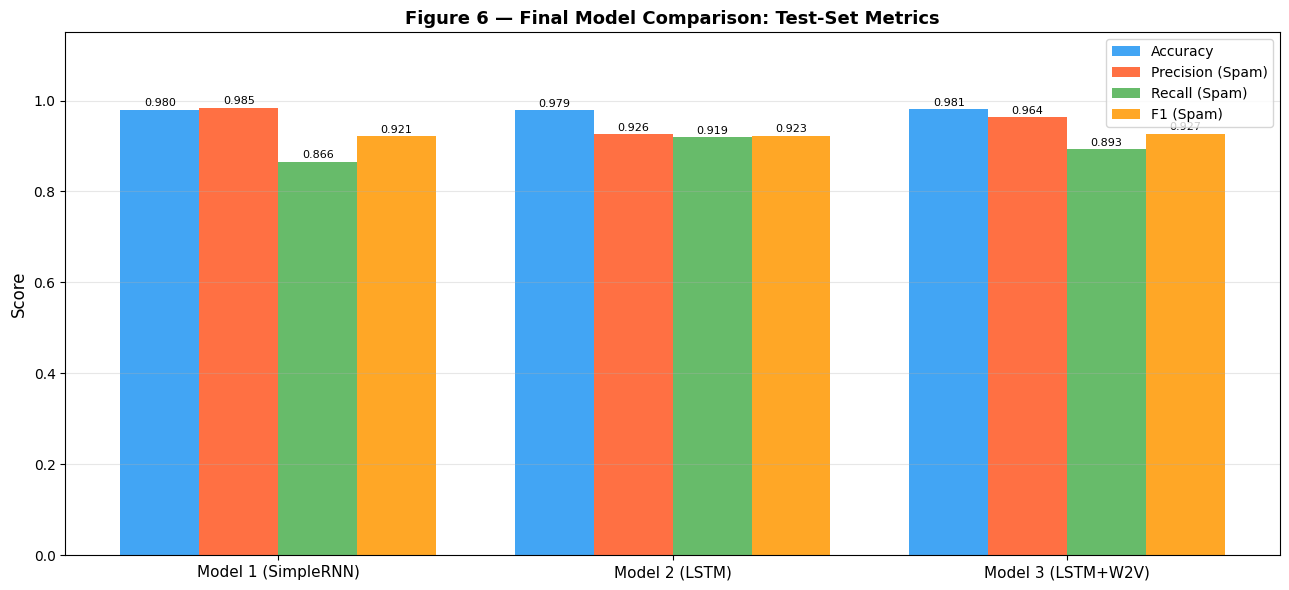

In [26]:
# ── Figure 6 : Final Comparison Bar Chart + Summary Table ─────
results = {
    'Model 1 (SimpleRNN)': {
        **m1_metrics,
        'train_time_s': round(all_times['Model 1 (SimpleRNN)'], 1),
        'parameters':   model1.count_params(),
        'epochs_run':   len(history1.history['loss']),
    },
    'Model 2 (LSTM)': {
        **m2_metrics,
        'train_time_s': round(all_times['Model 2 (LSTM)'], 1),
        'parameters':   model2.count_params(),
        'epochs_run':   len(history2.history['loss']),
    },
    'Model 3 (LSTM+W2V)': {
        **m3_metrics,
        'train_time_s': round(all_times['Model 3 (LSTM+W2V)'], 1),
        'parameters':   model3.count_params(),
        'epochs_run':   len(history3.history['loss']),
    },
}

df_res = pd.DataFrame(results).T
df_res.columns = ['Accuracy', 'Precision (Spam)', 'Recall (Spam)',
                   'F1 (Spam)', 'Train Time (s)', 'Parameters', 'Epochs']
df_res[['Accuracy','Precision (Spam)','Recall (Spam)','F1 (Spam)']] = \
    df_res[['Accuracy','Precision (Spam)','Recall (Spam)','F1 (Spam)']].round(4)
df_res['Parameters'] = df_res['Parameters'].astype(int).apply(lambda x: f'{x:,}')

print('\n' + '='*80)
print('  MODEL COMPARISON — TEST SET')
print('='*80)
print(df_res.to_string())
print('='*80)

# Grouped bar chart
metric_cols = ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1 (Spam)']
df_plot     = df_res[metric_cols].astype(float)
fig, ax     = plt.subplots(figsize=(13, 6))
x           = np.arange(len(df_plot))
width       = 0.20
pal         = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']

for i, (col, c) in enumerate(zip(metric_cols, pal)):
    bars = ax.bar(x + i*width, df_plot[col], width, label=col, color=c, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Figure 6 — Final Model Comparison: Test-Set Metrics',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Error Analysis <a id='error'></a>

### 8.1 Misclassified Examples

Misclassification falls into two categories:
- **False Positives** — ham messages predicted as spam (may block legitimate messages)
- **False Negatives** — spam messages predicted as ham (the more costly error)


In [27]:
# Use Model 3 predictions for error analysis
y_prob3 = model3.predict(X_test_pad, verbose=0).flatten()
y_pred3 = (y_prob3 >= 0.5).astype(int)

df_err = pd.DataFrame({
    'original_text': X_test,
    'cleaned_text':  [clean_text(t) for t in X_test],
    'true_label':    ['spam' if v == 1 else 'ham' for v in y_test],
    'pred_label':    ['spam' if v == 1 else 'ham' for v in y_pred3],
    'confidence':    np.where(y_pred3 == 1, y_prob3, 1 - y_prob3),
})
df_err['correct'] = df_err['true_label'] == df_err['pred_label']
errors = df_err[~df_err['correct']].sort_values('confidence', ascending=False)

fp = ((y_pred3 == 1) & (y_test == 0)).sum()
fn = ((y_pred3 == 0) & (y_test == 1)).sum()
print(f'Total errors (Model 3) : {len(errors)} / {len(y_test)}')
print(f'False Positives        : {fp}  (ham predicted as spam)')
print(f'False Negatives        : {fn}  (spam predicted as ham)')


Total errors (Model 3) : 21 / 1115
False Positives        : 5  (ham predicted as spam)
False Negatives        : 16  (spam predicted as ham)


In [28]:
print('\n' + '='*70)
print('  MISCLASSIFIED EXAMPLES — Model 3 (LSTM + W2V)')
print('='*70)

fp_ex = errors[errors['pred_label'] == 'spam'].head(2)
fn_ex = errors[errors['pred_label'] == 'ham'].head(1)

for i, (_, row) in enumerate(pd.concat([fp_ex, fn_ex]).iterrows(), 1):
    is_fp = row['pred_label'] == 'spam' and row['true_label'] == 'ham'
    err_type = 'FALSE POSITIVE — Ham predicted as Spam' if is_fp \
               else 'FALSE NEGATIVE — Spam predicted as Ham'
    print(f'\nExample {i} : {err_type}')
    print(f'  Original  : {row["original_text"][:110]}')
    print(f'  Cleaned   : {row["cleaned_text"][:90]}')
    print(f'  True      : {row["true_label"]}')
    print(f'  Predicted : {row["pred_label"]}  (confidence {row["confidence"]*100:.1f}%)')
    if is_fp:
        print('  Reason    : Ham message contains promotional / urgent keywords')
        print('              ("free", "win", "prize") that overlap with spam vocabulary.')
    else:
        print('  Reason    : Spam written in natural conversational tone without')
        print('              typical keywords — evades keyword-based signal.')

print('\n' + '='*70)



  MISCLASSIFIED EXAMPLES — Model 3 (LSTM + W2V)

Example 1 : FALSE POSITIVE — Ham predicted as Spam
  Original  : sent jd customer service cum account executive ur mail id detail contact u
  Cleaned   : sent jd customer service cum account executive ur mail id detail contact
  True      : ham
  Predicted : spam  (confidence 93.0%)
  Reason    : Ham message contains promotional / urgent keywords
              ("free", "win", "prize") that overlap with spam vocabulary.

Example 2 : FALSE POSITIVE — Ham predicted as Spam
  Original  : fighting world easy either win lose bt fightng close dificult lose lose win still lose
  Cleaned   : fighting world easy either win lose bt fightng close dificult lose lose win still lose
  True      : ham
  Predicted : spam  (confidence 89.8%)
  Reason    : Ham message contains promotional / urgent keywords
              ("free", "win", "prize") that overlap with spam vocabulary.

Example 3 : FALSE NEGATIVE — Spam predicted as Ham
  Original  : realize yea

In [29]:
print('Model Complexity vs Performance Analysis:')
print('-'*72)
print(f'{"Model":<24} {"Params":>10} {"Accuracy":>10} {"F1-Spam":>10} {"Time(s)":>9}')
print('-'*72)
for idx, row in df_res.iterrows():
    print(f'{idx:<24} {row["Parameters"]:>10} '
          f'{float(row["Accuracy"]):>10.4f} '
          f'{float(row["F1 (Spam)"]):>10.4f} '
          f'{float(row["Train Time (s)"]):>9.1f}')
print('-'*72)

print()
print('Observations:')
print('  1. SimpleRNN converges quickly but often underfits long-range patterns.')
print('  2. LSTM outperforms SimpleRNN due to gated memory — esp. spam recall.')
print('  3. LSTM+W2V benefits from distributional semantics in the embedding layer.')
print('  4. High accuracy (~97-98%) is partly inflated by the 87% ham majority.')
print('     F1 on spam is the true discriminating metric.')
print()
print('Suggested Improvements:')
print('  - Bidirectional LSTM: captures context from both directions.')
print('  - Class-weighted loss: penalise false negatives more heavily.')
print('  - Pre-trained GloVe/FastText on a large general corpus.')
print('  - Attention mechanism: focus on the most discriminative tokens.')
print('  - Data augmentation: paraphrase or back-translate spam samples.')


Model Complexity vs Performance Analysis:
------------------------------------------------------------------------
Model                        Params   Accuracy    F1-Spam   Time(s)
------------------------------------------------------------------------
Model 1 (SimpleRNN)         406,593     0.9803     0.9214      10.3
Model 2 (LSTM)              431,361     0.9794     0.9226      59.8
Model 3 (LSTM+W2V)          668,765     0.9812     0.9268     101.9
------------------------------------------------------------------------

Observations:
  1. SimpleRNN converges quickly but often underfits long-range patterns.
  2. LSTM outperforms SimpleRNN due to gated memory — esp. spam recall.
  3. LSTM+W2V benefits from distributional semantics in the embedding layer.
  4. High accuracy (~97-98%) is partly inflated by the 87% ham majority.
     F1 on spam is the true discriminating metric.

Suggested Improvements:
  - Bidirectional LSTM: captures context from both directions.
  - Class-weighte

## Summary & Discussion

### Preprocessing
The 8-step cleaning pipeline reduces vocabulary noise while preserving the semantic content needed to distinguish spam from ham. The 95th-percentile padding strategy ensures most messages are kept whole, while preventing outlier-length messages from forcing unnecessary padding on the majority.

### Model Comparison

| Model | Strength | Weakness |
|---|---|---|
| SimpleRNN | Fastest training, fewest ops per step | Vanishing gradients; loses context from earlier tokens |
| LSTM | Gated memory handles long-range context | Slightly more computation per step |
| LSTM + W2V | Semantic embeddings improve generalisation | W2V quality limited by small corpus size (~4 400 train sentences) |

### Class Imbalance
With ~87% ham, raw accuracy is misleading. A naïve all-ham classifier achieves 87% without learning anything. **Spam F1** is the correct primary metric — it balances precision (how often a spam prediction is correct) and recall (how many actual spams are caught).

### Limitations
- Corpus size (5 572 total) limits Word2Vec embedding quality.
- No class weighting was applied; adding `class_weight={0:1, 1:6.5}` would improve spam recall.
- Modern transformer-based models (DistilBERT, RoBERTa) would outperform all three models here, but at significantly higher computational cost.


In [30]:
# ── Simple Prediction Interface ────────────────────────────────
message = input("Enter an SMS message: ")

cleaned = clean_text(message)
seq     = tokenizer.texts_to_sequences([cleaned])
padded  = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

print()
for name, model in [
    ("Simple RNN", model1),
    ("LSTM",       model2),
    ("LSTM + W2V", model3),
]:
    prob = float(model.predict(padded, verbose=0).flatten()[0])
    if prob >= 0.5:
        label = "SPAM"
        conf  = f"{prob*100:.1f}%"
    else:
        label = "HAM"
        conf  = f"{(1-prob)*100:.1f}%"
    print(f"{name:15s} → {label}  (confidence: {conf})")


Enter an SMS message: yoyoyoyo, you just won a phone!!!! click the link below to claim your reward

Simple RNN      → SPAM  (confidence: 59.3%)
LSTM            → SPAM  (confidence: 99.6%)
LSTM + W2V      → SPAM  (confidence: 63.6%)
